In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, jaccard_score, hamming_loss
from scipy.spatial.distance import hamming, cosine
import random
import time
import csv
import json

### Evaluation of Test Set (503)

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

results_503 = pd.read_csv("results_gptoss.csv")
ground_truth = pd.read_csv("labels-level1_503.csv")

results_503 = results_503.drop(columns=["seconds"], errors="ignore")

y_true = ground_truth.set_index("Argument ID")
y_pred = results_503.set_index("Argument ID")

common = y_true.index.intersection(y_pred.index)
y_true = y_true.loc[common]
y_pred = y_pred.loc[common]

print("Number of samples:", len(y_true))
print("Number of samples in y_pred:", len(y_pred))

macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)

macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)

print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)

Number of samples: 503
Number of samples in y_pred: 503
Macro F1: 0.3113394388528163
Micro F1: 0.41345093715545755
Macro Precision: 0.31006475229003555
Macro Recall: 0.3917582097675748


- Micro > Macro (the LLM performs better on frequent values than on rare ones)
- Not very high values due to the complexity of the task (although similar to those previously obtained in other tests)

In [5]:
from sklearn.metrics import cohen_kappa_score

def kappa_global(y_true, y_pred):
    return cohen_kappa_score(
        y_true.values.flatten(),
        y_pred.values.flatten()
    )

print("Global Kappa:", kappa_global(y_true, y_pred))

from sklearn.metrics import jaccard_score

jaccard_per_arg = []

for i in range(len(y_true)):
    j = jaccard_score(y_true.iloc[i], y_pred.iloc[i])
    jaccard_per_arg.append(j)

print("Mean Jaccard:", np.mean(jaccard_per_arg))

exact_match = np.mean([
    np.array_equal(y_true.iloc[i].values, y_pred.iloc[i].values)
    for i in range(len(y_true))
])

print("Exact match:", exact_match)

Global Kappa: 0.35021827966042285
Mean Jaccard: 0.28269310488495375
Exact match: 0.0019880715705765406


- Kappa between fair agreement and moderate; it is considered low but not random. “Agreement beyond chance is non-trivial, indicating the model is not random but still far from human-level alignment.”
- Low Jaccard, indicating limited overlap between sets, but considering the moderate F1 and kappa, it can be concluded that: “The model partially overlaps with human annotations but tends to introduce additional or missing values.”
- Exact match is practically null; it never gets the full vector of 54 values correct: “Exact agreement is extremely rare due to the combinatorial nature of the task.”

GT avg labels: 4.495029821073559
LLM avg labels: 6.324055666003976
LLM arguments with > 10 labels: 6 (1.19%)


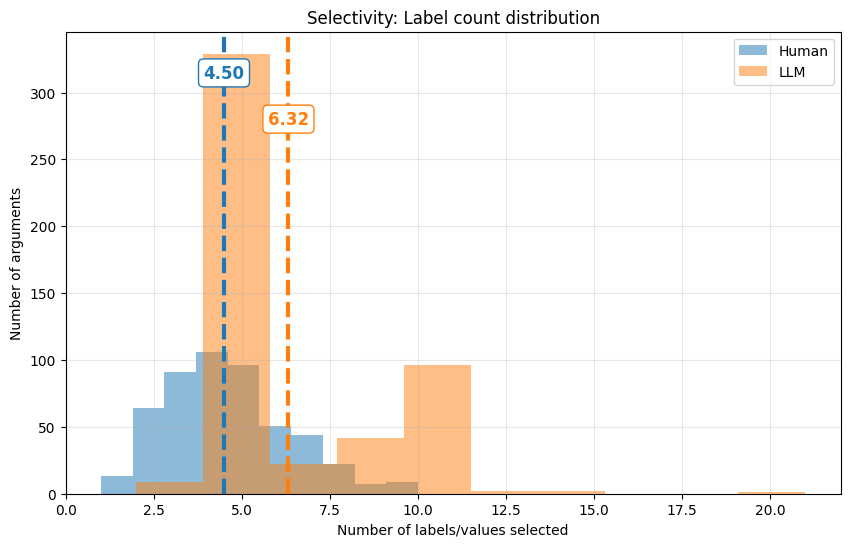

In [ ]:
import matplotlib.pyplot as plt

true_counts = y_true.sum(axis=1)
pred_counts = y_pred.sum(axis=1)

mean_true = true_counts.mean()
mean_pred = pred_counts.mean()

print("GT avg labels:", true_counts.mean()) 
print("LLM avg labels:", pred_counts.mean()) 
num_over_10 = (pred_counts > 10).sum() 
percentage_over_10 = (pred_counts > 10).mean() * 100 
print(f"LLM arguments with > 10 labels: {num_over_10} ({percentage_over_10:.2f}%)")

plt.figure(figsize=(10,6))

color_human = "tab:blue"
color_llm = "tab:orange"

plt.hist(true_counts, bins=10, alpha=0.5, label="Human", color=color_human)
plt.hist(pred_counts, bins=10, alpha=0.5, label="LLM", color=color_llm)

plt.axvline(mean_true, linestyle='--', linewidth=3, color=color_human)
plt.axvline(mean_pred, linestyle='--', linewidth=3, color=color_llm)

y_max = plt.ylim()[1]

plt.text(
    mean_true,
    y_max * 0.9,
    f"{mean_true:.2f}",
    color=color_human,
    fontsize=12,
    fontweight='bold',
    ha='center',
    bbox=dict(facecolor='white', edgecolor=color_human, boxstyle='round,pad=0.3')
)

plt.text(
    mean_pred,
    y_max * 0.8,
    f"{mean_pred:.2f}",
    color=color_llm,
    fontsize=12,
    fontweight='bold',
    ha='center',
    bbox=dict(facecolor='white', edgecolor=color_llm, boxstyle='round,pad=0.3')
)

plt.legend()
plt.xlabel("Number of labels/values selected")
plt.ylabel("Number of arguments")
plt.title("Selectivity: Label count distribution")

plt.grid(alpha=0.3)
plt.show()

In [ ]:
import json
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score,  f1_score, hamming_loss
import matplotlib.pyplot as plt


with open("values.json", "r", encoding="utf-8") as f:
    values_data = json.load(f)["values"]

value_map = pd.DataFrame(values_data)[
    ["name", "level2", "level3", "level4a", "level4b"]
]

def flatten_lists(df, col):
    df = df.copy()
    df[col] = df[col].apply(lambda x: x[0] if isinstance(x, list) else x)
    return df

value_map = flatten_lists(value_map, "level3")
value_map = flatten_lists(value_map, "level4a")
value_map = flatten_lists(value_map, "level4b")

groups = value_map.groupby("level2")["name"].apply(list)



In [ ]:
def aggregate_to_level(df, value_map, level_col):
    df = df.copy()

    if "Argument ID" in df.columns:
        ids = df["Argument ID"]
        df = df.drop(columns=["Argument ID"])
    else:
        ids = None

    mapping = value_map.groupby(level_col)["name"].apply(list)

    new_df = pd.DataFrame()

    for level_name, cols in mapping.items():
        existing_cols = [c for c in cols if c in df.columns]

        if len(existing_cols) == 0:
            continue

        new_df[level_name] = df[existing_cols].max(axis=1)

    if ids is not None:
        new_df.insert(0, "Argument ID", ids)

    return new_df

levels = ["level2", "level3", "level4a", "level4b"]

def generate_all_levels(df, value_map):
    level_dfs = {}
    for lvl in levels:
        level_dfs[lvl] = aggregate_to_level(df, value_map, lvl)
    return level_dfs

In [10]:
pred_levels = generate_all_levels(y_pred.reset_index(), value_map)
gt_levels = generate_all_levels(y_true.reset_index(), value_map)

for lvl in pred_levels:
    pred_levels[lvl] = pred_levels[lvl].set_index("Argument ID")
    gt_levels[lvl] = gt_levels[lvl].set_index("Argument ID")

In [ ]:
def plot_value_distribution(y_true, y_pred, title="Value Distribution", top_k=5):

    import matplotlib.pyplot as plt
    import numpy as np

    value_freq_true = y_true.mean(axis=0)
    value_freq_pred = y_pred.mean(axis=0)

    x = value_freq_true.values
    y = value_freq_pred.values
    labels = value_freq_true.index

    sizes = (x + y) * 3000 
    bias = y - x

    fig, ax = plt.subplots(figsize=(13, 9))

    scatter = ax.scatter(
        x, y,
        s=sizes,
        c=bias,
        cmap="coolwarm",
        alpha=0.7,
        edgecolors="black",
        linewidth=0.5
    )

    for i in range(len(x)):
        ax.text(x[i], y[i], str(i), fontsize=9, ha="center", va="center")

    idx_top = np.argsort(bias)[-top_k:]
    idx_bottom = np.argsort(bias)[:top_k]
    highlight_idx = set(np.concatenate([idx_top, idx_bottom]))

    for i in highlight_idx:
        ax.text(
            x[i], y[i], str(i),
            fontsize=11,
            fontweight='bold',
            ha="center",
            va="center"
        )

    max_val = max(max(x), max(y))
    ax.plot([0, max_val], [0, max_val], linestyle="--", color="gray")

    cbar = plt.colorbar(scatter)
    cbar.set_label("LLM - Human bias")

    ax.set_xlabel("Human frequency")
    ax.set_ylabel("LLM frequency")
    ax.set_title(title)
    ax.grid(True)

    y_pos = 0.95
    line_height = 0.018  
    
    for i, label in enumerate(labels):
        style = dict(fontsize=10)

        if i in highlight_idx:
            style["fontweight"] = "bold"

        fig.text(
            0.86,
            y_pos - i * line_height,
            f"{i}: {label}",
            ha="left",
            va="top",
            **style
        )

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

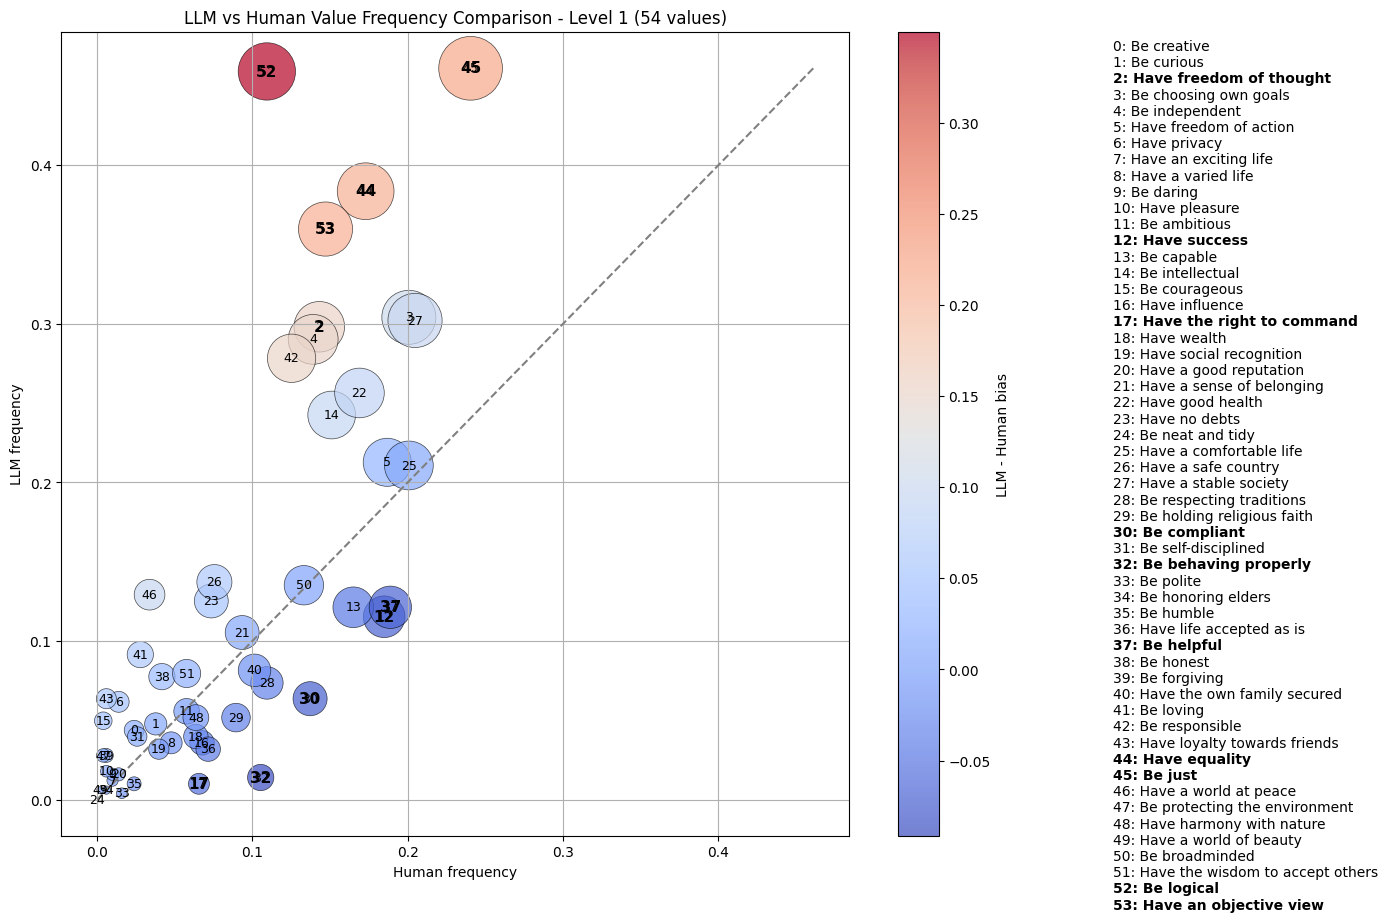

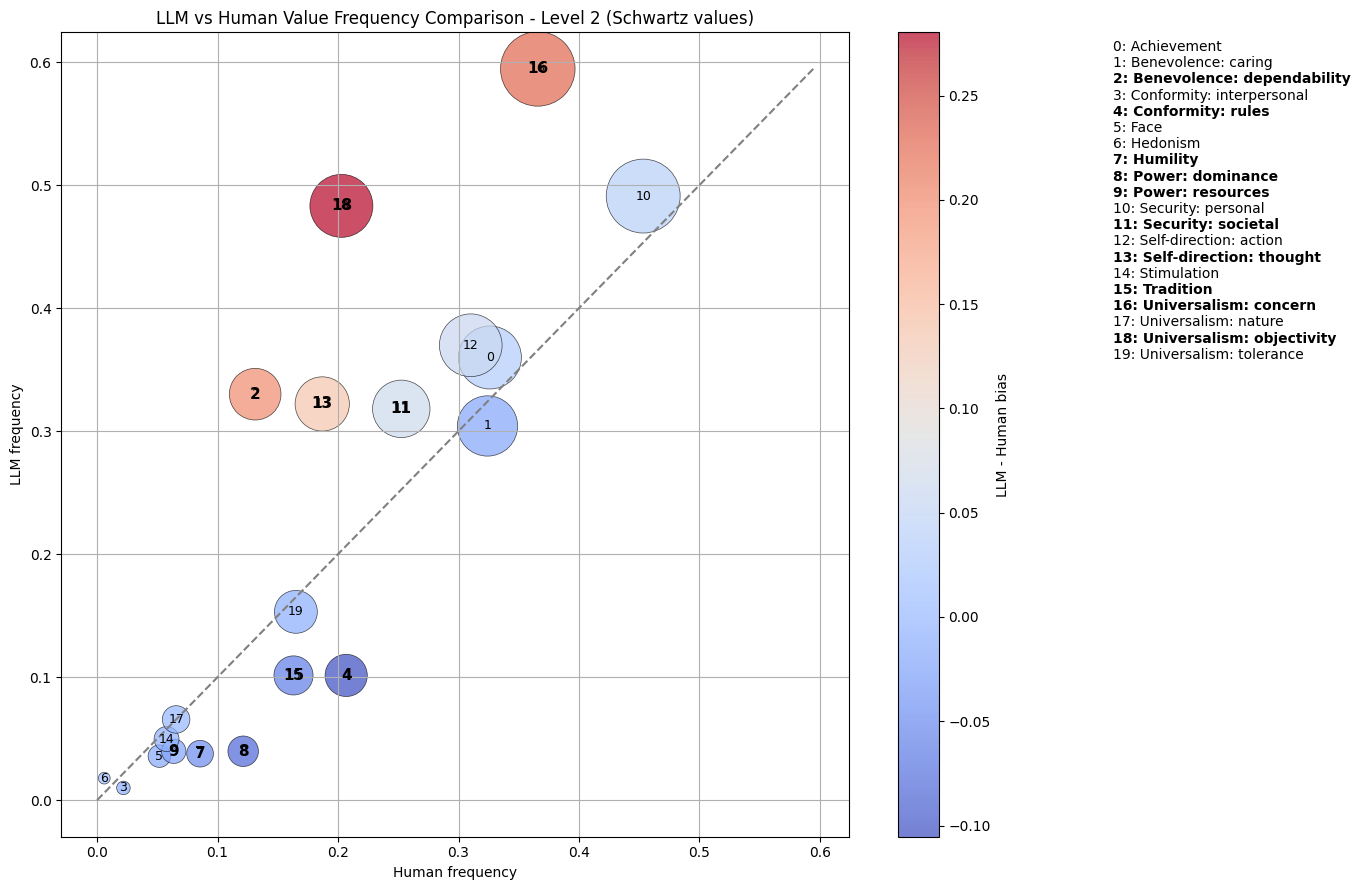

'\n# LEVEL 3\nplot_value_distribution(\n    gt_levels["level3"],\n    pred_levels["level3"],\n    title="Level 3"\n)\n\n# LEVEL 4A\nplot_value_distribution(\n    gt_levels["level4a"],\n    pred_levels["level4a"],\n    title="Level 4A"\n)\n\n# LEVEL 4B\nplot_value_distribution(\n    gt_levels["level4b"],\n    pred_levels["level4b"],\n    title="Level 4B"\n)'

In [ ]:
# LEVEL 1 (original)
plot_value_distribution(
    y_true,
    y_pred,
    title="LLM vs Human Value Frequency Comparison - Level 1 (54 values)"
)

# LEVEL 2
plot_value_distribution(
    gt_levels["level2"],
    pred_levels["level2"],
    title="LLM vs Human Value Frequency Comparison - Level 2 (Schwartz values)"
)


In [ ]:
for lvl in ["level2", "level3", "level4a", "level4b"]:
    print(f"--- {lvl} ---")

    f1 = f1_score(
        gt_levels[lvl],
        pred_levels[lvl],
        average="macro",
        zero_division=0
    )
    print("Macro F1-Score:", f1)

    f1 = f1_score(
        gt_levels[lvl],
        pred_levels[lvl],
        average="micro",
        zero_division=0
    )
    print("Micro F1-Score:", f1)

    macro_precision = precision_score(gt_levels[lvl], pred_levels[lvl], average="macro", zero_division=0)
    macro_recall = recall_score(gt_levels[lvl], pred_levels[lvl], average="macro", zero_division=0)


    print("Kappa:", kappa_global(gt_levels[lvl], pred_levels[lvl]))

    from sklearn.metrics import jaccard_score

    jaccard_per_arg = []

    for i in range(len(gt_levels[lvl])):
        j = jaccard_score(gt_levels[lvl].iloc[i], pred_levels[lvl].iloc[i])
        jaccard_per_arg.append(j)

    print("Mean Jaccard:", np.mean(jaccard_per_arg))

    
    exact_match = np.mean([
        np.array_equal(gt_levels[lvl].iloc[i].values, pred_levels[lvl].iloc[i].values)
        for i in range(len(gt_levels[lvl]))
    ])

    print("Exact match:", exact_match)


--- level2 ---
Macro F1-Score: 0.4082599449491281
Micro F1-Score: 0.5286006128702758
Kappa: 0.4157053362451433
Mean Jaccard: 0.384540658149008
Exact match: 0.02186878727634195
--- level3 ---
Macro F1-Score: 0.7610961837298571
Micro F1-Score: 0.7905652704351362
Kappa: 0.4616094457618981
Mean Jaccard: 0.6847249834327368
Exact match: 0.3220675944333996
--- level4a ---
Macro F1-Score: 0.9150159668176522
Micro F1-Score: 0.9148446490218642
Kappa: 0.37533354590766443
Mean Jaccard: 0.852882703777336
Exact match: 0.709741550695825
--- level4b ---
Macro F1-Score: 0.9184995581479831
Micro F1-Score: 0.9237718802936195
Kappa: 0.36385779193404844
Mean Jaccard: 0.8658051689860835
Exact match: 0.7375745526838966
